# Surrogate Replacement Workflow

This notebook demonstrates the full workflow for replacing a computationally expensive component in a multi-component OpenMDAO assembly with a surrogate model. The workflow uses `standard_evaluator` to:

1. **Build** a multi-component assembly with aerodynamics, structures, and performance groups
2. **Capture** the assembly interface and extract the expensive sub-group
3. **Train** a polynomial surrogate on the isolated sub-group
4. **Replace** the expensive component with the surrogate in the assembly description
5. **Compare** three evaluation approaches: original assembly, locally-replaced assembly, and a global surrogate

All components use `ExecComp` (no external dependencies), making this notebook fully reproducible. The aerodynamics group uses internal `connect()` calls to demonstrate proper handling of connection metadata.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import openmdao.api as om
import standard_evaluator as se
from standard_evaluator.evaluators import OpenMDAOEvaluator

matlabengine not available.


## 1. Creating the Multi-Component Assembly

We build an assembly with three sub-groups:

- **aero** — Aerodynamics group computing dynamic pressure, lift, and drag. Uses internal `connect()` to pass the pressure output to lift and drag calculations. Mark the variables and responses that are internal with the 'internal' tag.
- **structures** — Structural analysis computing weight and stress from material/geometry parameters.
- **performance** — Performance metric combining aero and fuel parameters to compute range.

The top-level assembly uses promotions (`promotes=['*']`) to connect the groups together.

In [2]:
# Build the assembly
assembly = om.Group()

# --- Aero group (with internal connect) ---
aero = om.Group()
aero.add_subsystem(
    'pressure_calc',
    om.ExecComp('pressure = 0.5 * rho * v**2', pressure={'tags': 'internal'}),
    promotes_inputs=['rho', 'v']
)
aero.add_subsystem(
    'lift_calc',
    om.ExecComp('lift = cl * q * area', q={'tags': 'internal'}),
    promotes_inputs=['cl', 'area'],
    promotes_outputs=['lift']
)
aero.add_subsystem(
    'drag_calc',
    om.ExecComp('drag = cd * q * area', q={'tags': 'internal'}),
    promotes_inputs=['cd', 'area'],
    promotes_outputs=['drag']
)
# Internal connections: pressure output feeds lift and drag calculations
aero.connect('pressure_calc.pressure', 'lift_calc.q')
aero.connect('pressure_calc.pressure', 'drag_calc.q')

# --- Structures group ---
structures = om.Group()
structures.add_subsystem(
    'weight_calc',
    om.ExecComp('weight = density * volume * 9.81'),
    promotes_inputs=['density', 'volume'],
    promotes_outputs=['weight']
)
structures.add_subsystem(
    'stress_calc',
    om.ExecComp('stress = force / area_struct'),
    promotes_inputs=['force', 'area_struct'],
    promotes_outputs=['stress']
)

# --- Performance group ---
performance = om.Group()
performance.add_subsystem(
    'range_calc',
    om.ExecComp('range_out = (lift / drag) * (fuel / sfc)'),
    promotes_inputs=['lift', 'drag', 'fuel', 'sfc'],
    promotes_outputs=['range_out']
)

# --- Top-level assembly with promotions ---
assembly.add_subsystem('aero', aero, promotes=['*'])
assembly.add_subsystem('structures', structures, promotes=['*'])
assembly.add_subsystem('performance', performance, promotes=['*'])

# Create and setup the problem
prob = om.Problem(model=assembly)
prob.setup()
prob.final_setup()

# Set input values
prob.set_val('rho', 1.225)       # air density [kg/m^3]
prob.set_val('v', 50.0)          # velocity [m/s]
prob.set_val('cl', 0.5)          # lift coefficient
prob.set_val('cd', 0.03)         # drag coefficient
prob.set_val('area', 20.0)       # wing area [m^2]
prob.set_val('density', 2700.0)  # material density [kg/m^3]
prob.set_val('volume', 0.01)     # structural volume [m^3]
prob.set_val('force', 5000.0)    # applied force [N]
prob.set_val('area_struct', 0.005)  # structural cross-section area [m^2]
prob.set_val('fuel', 500.0)      # fuel mass [kg]
prob.set_val('sfc', 0.5)         # specific fuel consumption [1/hr]

prob.run_model()

print('Assembly outputs:')
print(f"  pressure = {prob.get_val('aero.pressure_calc.pressure')[0]:.4f} Pa")
print(f"  lift     = {prob.get_val('lift')[0]:.4f} N")
print(f"  drag     = {prob.get_val('drag')[0]:.4f} N")
print(f"  weight   = {prob.get_val('weight')[0]:.4f} N")
print(f"  stress   = {prob.get_val('stress')[0]:.4f} Pa")
print(f"  range    = {prob.get_val('range_out')[0]:.4f}")

Assembly outputs:
  pressure = 1531.2500 Pa
  lift     = 15312.5000 N
  drag     = 918.7500 N
  weight   = 264.8700 N
  stress   = 1000000.0000 Pa
  range    = 16666.6667


## 2. Capturing the Interface and Extracting the Aero Sub-Group

With the assembly built and verified, we now use `standard_evaluator` to:

1. **Capture** the full assembly interface as a serializable `GroupInfo` description using `se.get_interface()`
2. **Display** the hierarchical structure with `se.show_structure()` to see all components, inputs, outputs, promotions, and linkages
3. **Extract** the aerodynamics sub-group from the assembly description and reconstruct it as a standalone OpenMDAO Problem using `se.create_problem()`
4. **Wrap** the extracted problem as an `OpenMDAOEvaluator` so it can be sampled for surrogate training

This demonstrates the key capability of `standard_evaluator`: converting between live OpenMDAO assemblies and portable interface descriptions that can be inspected, modified, and reconstructed.

Note: If there are connections that are made inside a group that should stay internal it is important to add the `internal` tag to the inputs or outputs.

In [3]:
# Capture the full assembly interface as a GroupInfo description
assembly_info = se.get_interface(assembly)

se.set_variable_bounds(assembly_info, {
    'rho': (0.5, 2.0), 'v': (10, 100),
    'cl': (0.1, 1.5), 'cd': (0.01, 0.3), 'area': (5, 50),
    'density': (2000, 4000), 'volume': (0.001, 0.5),
    'force': (4000.0, 6000.0), 'area_struct': (0.002, 0.008),
    'fuel': (300.0, 600.0), 'sfc': (0.3, 0.8) })
# Build the se problem with those bounds
full_opt_problem = se.build_opt_problem(assembly_info, prob)

# Display the hierarchical assembly structure
print("Assembly structure:")
print("=" * 60)
se.show_structure(assembly_info)
print(full_opt_problem)

Assembly structure:
 1  15 6
 Inputs:  ['area', 'cd', 'drag_calc.q', 'cl', 'lift_calc.q', 'rho', 'v', 'drag', 'fuel', 'lift', 'sfc', 'area_struct', 'force', 'density', 'volume']
 Outputs: ['drag', 'lift', 'pressure_calc.pressure', 'range_out', 'stress', 'weight']
 Promotions: {'aero': [('area', 'area'), ('cd', 'cd'), ('area', 'area'), ('cl', 'cl'), ('rho', 'rho'), ('v', 'v'), ('drag', 'drag'), ('lift', 'lift')], 'structures': [('area_struct', 'area_struct'), ('force', 'force'), ('density', 'density'), ('volume', 'volume'), ('stress', 'stress'), ('weight', 'weight')], 'performance': [('drag', 'drag'), ('fuel', 'fuel'), ('lift', 'lift'), ('sfc', 'sfc'), ('range_out', 'range_out')]}
 Linkage   : []
   2 aero 7 3
   Inputs:  ['area', 'cd', 'drag_calc.q', 'cl', 'lift_calc.q', 'rho', 'v']
   Outputs: ['drag', 'lift', 'pressure_calc.pressure']
   Promotions: {'pressure_calc': [('rho', 'rho'), ('v', 'v')], 'lift_calc': [('area', 'area'), ('cl', 'cl'), ('lift', 'lift')], 'drag_calc': [('area', 

In [4]:
import copy

# Extract the aero sub-group info from the assembly description
aero_info = copy.deepcopy(assembly_info.components['aero'])

# Set bounds on the serializable interface description
se.set_variable_bounds(aero_info, {
    'rho': (0.5, 2.0), 'v': (10, 100),
    'cl': (0.1, 1.5), 'cd': (0.01, 0.3), 'area': (5, 50),
})

# Reconstruct the aero sub-group as a standalone Problem
aero_prob = se.create_problem(aero_info)

# Build the se problem and evaluator with those bounds
opt_problem = se.build_opt_problem(aero_info)
aero_evaluator = OpenMDAOEvaluator(aero_prob, opt_problem=opt_problem)

print("Aero evaluator inputs:", aero_evaluator.inputs)
print("Aero evaluator outputs:", aero_evaluator.outputs)
print("Bounds on the inputs:")
for var in aero_evaluator.opt_problem.variables:
    print(f"{var.name}: {var.bounds}")

Adding pressure_calc component
Building Equation class pressure_calc
Adding lift_calc component
Building Equation class lift_calc
Adding drag_calc component
Building Equation class drag_calc
Aero evaluator inputs: ['area', 'cd', 'cl', 'rho', 'v']
Aero evaluator outputs: ['drag', 'lift']
Bounds on the inputs:
area: (5.0, 50.0)
cd: (0.01, 0.3)
cl: (0.1, 1.5)
rho: (0.5, 2.0)
v: (10.0, 100.0)


## 3. Training a Polynomial Surrogate

With the aero sub-group isolated as an evaluator, we can now train a polynomial surrogate to approximate it. The steps are:

1. **Generate training sites** — Sample input combinations uniformly within the variable bounds of the aero evaluator
2. **Evaluate training sites** — Run the aero evaluator on all training sites to get true response values
3. **Build the surrogate** — Fit a degree-4 polynomial model to the training data
4. **Wrap as OpenMDAO component** — Use `EvaluatorOpenMdaoComponent` to make the surrogate usable inside an OpenMDAO assembly
5. **Create surrogate evaluator** — Wrap the surrogate component in a Problem and then in an `OpenMDAOEvaluator`

A degree-2 polynomial is sufficient for these simple ExecComp equations and provides a fast approximation.

In [5]:
from standard_evaluator.surrogate_models import PolynomialModel, PolynomialModelOptions
from standard_evaluator.components import EvaluatorOpenMdaoComponent
from scipy.stats.qmc import LatinHypercube, scale

# --- Step 1: Generate training sites within the aero evaluator bounds ---
num_independent = len(aero_evaluator.inputs)
n_train = int(2*(num_independent+1)*(num_independent+2)/2)

# Use an optimized Latin Hypercube for better space-filling
sampler = LatinHypercube(d=num_independent, optimization='random-cd', seed=42)
sample_unit = sampler.random(n=n_train)

# Scale from [0,1]^d to the variable bounds
lower_bounds = [var.bounds[0] for var in aero_evaluator.opt_problem.variables]
upper_bounds = [var.bounds[1] for var in aero_evaluator.opt_problem.variables]
sample_scaled = scale(sample_unit, lower_bounds, upper_bounds)

# Build training DataFrame
train_data = {}
for i, var in enumerate(aero_evaluator.opt_problem.variables):
    train_data[var.name] = sample_scaled[:, i]
    print(f"Bounds on {var.name}: [{var.bounds[0]}, {var.bounds[1]}]")

train_sites = pd.DataFrame(train_data)

# --- Step 2: Evaluate training sites using the aero evaluator ---
aero_evaluator(train_sites)

print(f"Training data shape: {train_sites.shape}")
print(f"Input columns: {aero_evaluator.inputs}")
print(f"Output columns: {aero_evaluator.outputs}")
train_sites.head()

Bounds on area: [5.0, 50.0]
Bounds on cd: [0.01, 0.3]
Bounds on cl: [0.1, 1.5]
Bounds on rho: [0.5, 2.0]
Bounds on v: [10.0, 100.0]
Training data shape: (42, 7)
Input columns: ['area', 'cd', 'cl', 'rho', 'v']
Output columns: ['drag', 'lift']


,area,cd,cl,rho,v,drag,lift
0,21.854305,0.019973,0.535375,1.727022,13.669763,70.430865,1887.926848
1,47.782144,0.273703,0.555257,1.791096,63.180365,46751.780334,94844.575612
2,37.939727,0.085046,1.121449,0.510428,70.980793,4148.923639,54709.147546
3,31.939632,0.202131,0.992580,1.266121,11.492905,539.844434,2650.943251
4,12.020839,0.100396,1.342098,1.126117,56.088375,2137.721615,28577.089740


In [6]:
train_sites.describe()

,area,cd,cl,rho,v,drag,lift
count,42.000000,42.000000,42.000000,42.000000,42.000000,42.000000,42.000000
mean,25.215543,0.150058,0.796259,1.210893,53.262626,8094.077192,45310.094484
std,13.187044,0.092821,0.396725,0.431699,28.273113,11761.327271,62230.745963
min,5.926302,0.011601,0.135587,0.510428,10.455543,31.305816,235.820412
25%,13.199893,0.067033,0.463170,0.866731,24.833183,967.795957,4090.310929
50%,24.622194,0.141768,0.801656,1.180148,58.818313,3470.200513,17630.928711
75%,34.976210,0.234579,1.163267,1.542947,74.548107,9342.681355,62396.401950
max,48.645943,0.296197,1.401577,1.978476,94.305699,46751.780334,249123.848972


In [7]:
# --- Step 3: Build a degree-2 polynomial surrogate from training data ---
# Create an opt_problem with only the external outputs for the surrogate
from standard_evaluator.problem import OptProblem, FloatVariable

poly_options = PolynomialModelOptions(degree=2)

surrogate = PolynomialModel(
    sites=train_sites,
    options=poly_options,
    opt_problem=aero_evaluator.opt_problem,
)

print(f"Surrogate inputs: {surrogate.inputs}")
print(f"Surrogate outputs: {surrogate.outputs}")
print(f"Number of polynomial terms: {surrogate.nterms}")
print(f"Polynomial degree: {surrogate.degree}")

Surrogate inputs: ['area', 'cd', 'cl', 'rho', 'v']
Surrogate outputs: ['drag', 'lift']
Number of polynomial terms: 21
Polynomial degree: 2


### 3.1 Checking the quality of the local model

We explore how well the local model does in approximating the aero component.

In [8]:
# --- Generate test sites (distinct from training data) ---
n_test = 30

# Use an optimized Latin Hypercube with a different seed for test points
test_sampler = LatinHypercube(d=num_independent, optimization='random-cd', seed=999)
test_unit = test_sampler.random(n=n_test)
test_scaled = scale(test_unit, lower_bounds, upper_bounds)

test_data = {}
for i, var in enumerate(aero_evaluator.opt_problem.variables):
    test_data[var.name] = test_scaled[:, i]

# Create separate DataFrames for each evaluator (they modify in place)
test_sites_original = pd.DataFrame(test_data).copy()
test_sites_modified = pd.DataFrame(test_data).copy()

# --- Evaluate all three ---
# 1. Original assembly (ground truth)
aero_evaluator(test_sites_original)

# 2. Locally-replaced assembly
surrogate(test_sites_modified)

print(f"Test sites: {n_test} points")
print(f"Responses being compared: {aero_evaluator.outputs}")
# --- Compute error metrics ---
# Using original as baseline truth
error_records = []

for response in aero_evaluator.outputs:
    actual = test_sites_original[response].values

    # Local surrogate-replaced assembly errors
    if response in test_sites_modified.columns:
        pred_local = test_sites_modified[response].values
        abs_err_local = np.abs(pred_local - actual)
        rel_err_local = np.abs((pred_local - actual)/actual)
        error_records.append({
            'Response': response,
            'Evaluator': 'Local Surrogate',
            'Mean Absolute Error': abs_err_local.mean(),
            'Max Absolute Error': abs_err_local.max(),
            'Mean Relative Error': rel_err_local.mean(),
            'Max Relative Error': rel_err_local.max(),
        })

error_df = pd.DataFrame(error_records)

# Display summary table
print("Error Summary (relative to original assembly):")
print("=" * 70)
error_df

Test sites: 30 points (seed=999)
Responses being compared: ['drag', 'lift']
Error Summary (relative to original assembly):


,Response,Evaluator,Mean Absolute Error,Max Absolute Error,Mean Relative Error,Max Relative Error
0,drag,Local Surrogate,4139.741124,14897.962218,3.524918,69.149178
1,lift,Local Surrogate,26526.657963,127751.596242,1.934994,11.450473


In [9]:
# --- Step 4: Wrap the surrogate as an OpenMDAO component ---
surrogate_component = EvaluatorOpenMdaoComponent(surrogate)

# --- Step 5: Create a Problem wrapping the surrogate component ---
surrogate_prob = om.Problem()
surrogate_prob.model.add_subsystem(
    'surrogate', surrogate_component, promotes=['*']
)
surrogate_prob.setup()
surrogate_prob.final_setup()

# Wrap the surrogate Problem as an OpenMDAOEvaluator
surrogate_evaluator = OpenMDAOEvaluator(
    surrogate_prob, scan_model=True, use_defined_problem=False
)

print(f"Surrogate evaluator inputs: {surrogate_evaluator.inputs}")
print(f"Surrogate evaluator outputs: {surrogate_evaluator.outputs}")

Surrogate evaluator inputs: ['area', 'cd', 'cl', 'rho', 'v']
Surrogate evaluator outputs: ['drag', 'lift']


## 4. Replacing the Aero Component with the Surrogate

Now we perform the key step: replacing the expensive aero sub-group in the assembly's interface description with the trained surrogate. The process is:

1. **Capture** the surrogate evaluator's interface using `se.get_interface()` to obtain its `EvaluatorInfo`
2. **Replace** the `'aero'` entry in the original assembly's `GroupInfo.components` dictionary with the surrogate's `EvaluatorInfo`
3. **Reconstruct** the modified assembly using `se.create_problem()` to demonstrate the full round-trip
4. **Wrap** the modified assembly as an `OpenMDAOEvaluator` for evaluation

This demonstrates that `standard_evaluator`'s interface descriptions are fully editable — you can swap components at the description level and rebuild a working assembly.

In [10]:
# --- Step 1: Capture the surrogate's interface as an EvaluatorInfo ---
surrogate_group_info = se.get_interface(surrogate_prob.model)
surrogate_eval_info = surrogate_group_info.components['surrogate']

print(f"Surrogate interface type: {surrogate_eval_info.class_type}")
print(f"Surrogate inputs: {[v.name for v in surrogate_eval_info.inputs]}")
print(f"Surrogate outputs: {[v.name for v in surrogate_eval_info.outputs]}")

# --- Step 2: Replace aero in the assembly description ---
modified_info = copy.deepcopy(assembly_info)
modified_info.components['aero'] = surrogate_eval_info

# --- Step 3: Instantiate the modified assembly ---
modified_prob = se.create_problem(modified_info)

# --- Step 4: Wrap as OpenMDAOEvaluator ---
modified_evaluator = OpenMDAOEvaluator(
    modified_prob, opt_problem=full_opt_problem
)

print(f"\nModified assembly evaluator inputs: {modified_evaluator.inputs}")
print(f"Modified assembly evaluator outputs: {modified_evaluator.outputs}")

Surrogate interface type: EvaluatorInfo
Surrogate inputs: ['area', 'cd', 'cl', 'rho', 'v']
Surrogate outputs: ['drag', 'lift']
Adding aero component
Building class surrogate
Importing class EvaluatorOpenMdaoComponent from standard_evaluator.components.evaluator_om_component
** This is a group, special handling needed for structures in group 
Adding weight_calc component
Building Equation class weight_calc
Adding stress_calc component
Building Equation class stress_calc
** This is a group, special handling needed for performance in group 
Adding range_calc component
Building Equation class range_calc

Modified assembly evaluator inputs: ['area', 'cd', 'cl', 'rho', 'v', 'fuel', 'sfc', 'area_struct', 'force', 'density', 'volume']
Modified assembly evaluator outputs: ['drag', 'lift', 'range_out', 'stress', 'weight']


## 5. Building a Global Surrogate

As an alternative to the local replacement strategy, we can build a **global surrogate** that maps the full assembly's inputs directly to all outputs, bypassing the component structure entirely.

The process is:

1. **Wrap the original assembly** as an `OpenMDAOEvaluator` so we can sample it
2. **Generate training data** — Evaluate the original assembly on Latin Hypercube samples
3. **Build a PolynomialModel** (degree=2) that approximates the full input→output mapping

This approach trades structural fidelity for simplicity: a single polynomial replaces the entire assembly. It works well when the assembly's overall behavior is smooth and low-dimensional, but loses the ability to swap individual components.

In [11]:


# --- Step 1: Wrap the original assembly as an OpenMDAOEvaluator ---
original_evaluator = OpenMDAOEvaluator(prob, opt_problem=full_opt_problem)



print(f"Original assembly evaluator inputs: {original_evaluator.inputs}")
print(f"Original assembly evaluator outputs: {original_evaluator.outputs}")

Original assembly evaluator inputs: ['area', 'cd', 'cl', 'rho', 'v', 'fuel', 'sfc', 'area_struct', 'force', 'density', 'volume']
Original assembly evaluator outputs: ['drag', 'lift', 'range_out', 'stress', 'weight']


In [12]:
# --- Step 2: Generate training data for the global surrogate ---
num_independent = len(aero_evaluator.inputs)
n_train_global = int(2*(num_independent+1)*(num_independent+2)/2)

# Use an optimized Latin Hypercube for the global training data
global_num_vars = len(original_evaluator.opt_problem.variables)
global_sampler = LatinHypercube(d=global_num_vars, optimization='random-cd', seed=123)
global_sample_unit = global_sampler.random(n=n_train_global)

global_lower = [var.bounds[0] for var in original_evaluator.opt_problem.variables]
global_upper = [var.bounds[1] for var in original_evaluator.opt_problem.variables]
global_sample_scaled = scale(global_sample_unit, global_lower, global_upper)

# Build training DataFrame
global_train_data = {}
for i, var in enumerate(original_evaluator.opt_problem.variables):
    print(f"{var.name}: {var.bounds}")
    global_train_data[var.name] = global_sample_scaled[:, i]

global_train_sites = pd.DataFrame(global_train_data)

# Evaluate the original assembly on all training sites
original_evaluator(global_train_sites)

print(f"Global training data shape: {global_train_sites.shape}")
print(f"Input columns: {original_evaluator.inputs}")
print(f"Output columns: {original_evaluator.outputs}")
global_train_sites.head()

area: (5.0, 50.0)
cd: (0.01, 0.3)
cl: (0.1, 1.5)
rho: (0.5, 2.0)
v: (10.0, 100.0)
fuel: (300.0, 600.0)
sfc: (0.3, 0.8)
area_struct: (0.002, 0.008)
force: (4000.0, 6000.0)
density: (2000.0, 4000.0)
volume: (0.001, 0.5)
Global training data shape: (42, 16)
Input columns: ['area', 'cd', 'cl', 'rho', 'v', 'fuel', 'sfc', 'area_struct', 'force', 'density', 'volume']
Output columns: ['drag', 'lift', 'range_out', 'stress', 'weight']


,area,cd,cl,rho,v,fuel,sfc,area_struct,force,density,volume,drag,lift,range_out,stress,weight
0,36.341113,0.102013,1.395185,0.886313,77.564530,537.689791,0.657801,0.002893,4779.748461,3559.533324,0.255191,9884.082331,135180.385151,11179.305527,1.652368e+06,8911.036251
1,17.876270,0.130300,1.278338,1.346539,61.665744,455.614977,0.505260,0.007640,5509.594163,2474.956440,0.149154,5963.438572,58505.858998,8846.791188,7.211346e+05,3621.354611
2,15.208315,0.261230,0.600357,1.710453,77.647959,427.760308,0.395503,0.006996,4738.582349,2665.160539,0.475176,20485.418205,47079.478208,2485.632873,6.772986e+05,12423.571903
3,29.809165,0.082632,0.161028,1.091555,17.123406,536.456152,0.783747,0.007076,4484.439613,3907.394239,0.408167,394.179791,768.152289,1333.863004,6.337240e+05,15645.671677
4,37.376104,0.150080,0.526675,1.596610,87.345017,423.470767,0.625375,0.002744,5875.336714,3315.630146,0.162164,34163.444889,119889.727328,2376.310069,2.141518e+06,5274.599977


In [13]:
# --- Step 3: Build a degree-2 polynomial mapping all assembly inputs to all outputs ---

global_poly_options = PolynomialModelOptions(degree=2)

global_surrogate = PolynomialModel(
    sites=global_train_sites,
    options=global_poly_options,
    opt_problem=full_opt_problem,
)

print(f"Global surrogate inputs: {global_surrogate.inputs}")
print(f"Global surrogate outputs: {global_surrogate.outputs}")
print(f"Number of polynomial terms: {global_surrogate.nterms}")
print(f"Polynomial degree: {global_surrogate.degree}")

Global surrogate inputs: ['area', 'cd', 'cl', 'rho', 'v', 'fuel', 'sfc', 'area_struct', 'force', 'density', 'volume']
Global surrogate outputs: ['drag', 'lift', 'range_out', 'stress', 'weight']
Number of polynomial terms: 78
Polynomial degree: 2


## 6. Comparing All Three Evaluators

We now compare the three evaluation approaches on a fresh set of **test sites** (distinct from training data) to assess accuracy:

1. **Original assembly** — The ground truth reference (full OpenMDAO evaluation)
2. **Locally-replaced assembly** — The assembly with the aero sub-group replaced by a local polynomial surrogate, while structures and performance groups remain as original components
3. **Global surrogate** — A single polynomial mapping all assembly inputs directly to outputs

**Methodology:**
- Generate 30 random test sites using a distinct random seed (`seed=999`)
- Evaluate all three approaches on the same test sites
- Use the original assembly outputs as ground truth
- Compute Mean Absolute Error (MAE) and Max Absolute Error for each response per evaluator
- Visualize with scatter plots (predicted vs actual) and percent error box plots

In [14]:
# --- Generate test sites (distinct from training data) ---
n_test = 30

# Use an optimized Latin Hypercube with a different seed
global_test_sampler = LatinHypercube(d=global_num_vars, optimization='random-cd', seed=999)
global_test_unit = global_test_sampler.random(n=n_test)
global_test_scaled = scale(global_test_unit, global_lower, global_upper)

test_data = {}
for i, var in enumerate(original_evaluator.opt_problem.variables):
    test_data[var.name] = global_test_scaled[:, i]

# Create separate DataFrames for each evaluator (they modify in place)
test_sites_original = pd.DataFrame(test_data).copy()
test_sites_modified = pd.DataFrame(test_data).copy()
test_sites_global = pd.DataFrame(test_data).copy()

# --- Evaluate all three ---
# 1. Original assembly (ground truth)
original_evaluator(test_sites_original)

# 2. Locally-replaced assembly
modified_evaluator(test_sites_modified)

# 3. Global surrogate (PolynomialModel, call directly with DataFrame)
global_surrogate(test_sites_global)

print(f"Test sites: {n_test} points (seed=999)")
print(f"Responses being compared: {original_evaluator.outputs}")

Test sites: 30 points (seed=999)
Responses being compared: ['drag', 'lift', 'range_out', 'stress', 'weight']


In [15]:
# --- Compute error metrics ---
# Using original as baseline truth
error_records = []

for response in original_evaluator.outputs:
    actual = test_sites_original[response].values

    # Local surrogate-replaced assembly errors
    if response in test_sites_modified.columns:
        pred_local = test_sites_modified[response].values
        abs_err_local = np.abs(pred_local - actual)
        rel_err_local = np.abs((pred_local - actual)/actual)
        error_records.append({
            'Response': response,
            'Evaluator': 'Local Surrogate',
            'Mean Absolute Error': abs_err_local.mean(),
            'Max Absolute Error': abs_err_local.max(),
            'Mean Relative Error': rel_err_local.mean(),
            'Max Relative Error': rel_err_local.max(),
        })

    # Global surrogate errors
    if response in test_sites_global.columns:
        pred_global = test_sites_global[response].values
        abs_err_global = np.abs(pred_global - actual)
        rel_err_global = np.abs((pred_global - actual)/actual)
        error_records.append({
            'Response': response,
            'Evaluator': 'Global Surrogate',
            'Mean Absolute Error': abs_err_global.mean(),
            'Max Absolute Error': abs_err_global.max(),
            'Mean Relative Error': rel_err_global.mean(),
            'Max Relative Error': rel_err_global.max(),
        })

error_df = pd.DataFrame(error_records)

# Display summary table
print("Error Summary (relative to original assembly):")
print("=" * 70)
error_df

Error Summary (relative to original assembly):


,Response,Evaluator,Mean Absolute Error,Max Absolute Error,Mean Relative Error,Max Relative Error
0,drag,Local Surrogate,4139.741124,14897.962218,3.524918,69.149178
1,drag,Global Surrogate,11366.413114,35835.889359,7.271962,65.113192
2,lift,Local Surrogate,26526.657963,127751.596242,1.934994,11.450473
3,lift,Global Surrogate,57745.720419,195375.099986,9.633349,100.440648
4,range_out,Local Surrogate,21922.688711,449559.948260,1.746650,15.915525
5,range_out,Global Surrogate,39085.976700,118865.723123,14.483950,89.140227
6,stress,Local Surrogate,0.000000,0.000000,0.000000,0.000000
7,stress,Global Surrogate,381242.026671,986695.173747,0.333294,1.084431
8,weight,Local Surrogate,0.000000,0.000000,0.000000,0.000000
9,weight,Global Surrogate,3.219108,7.542319,0.000897,0.005315


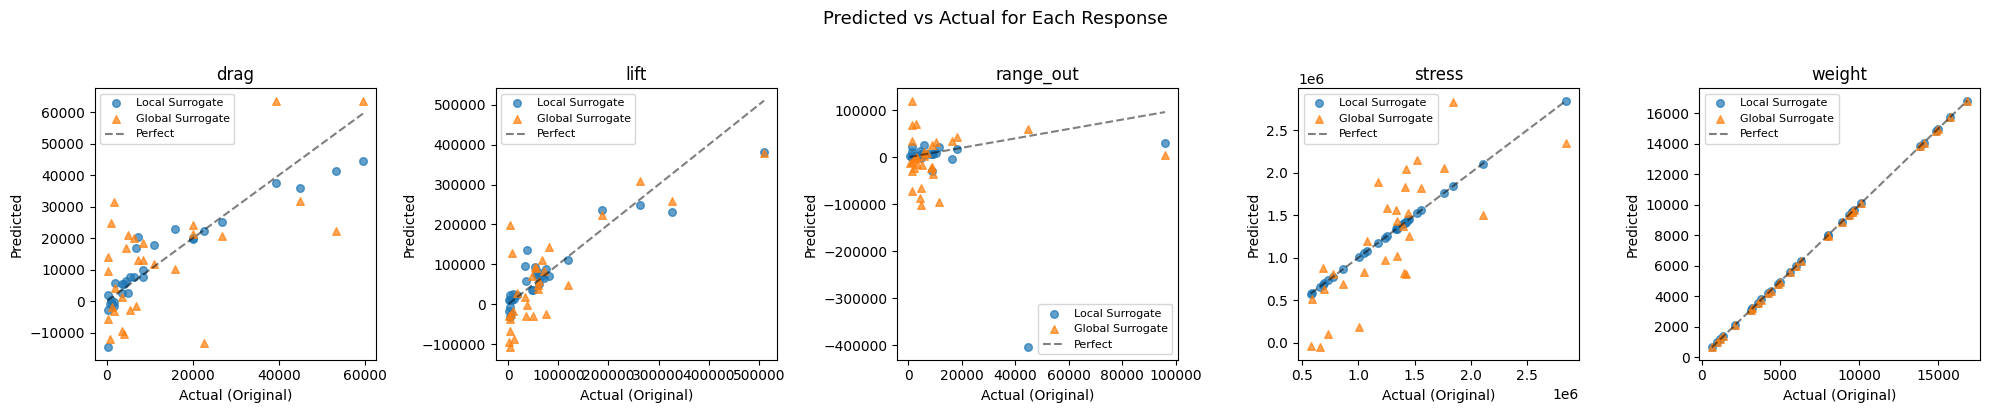

In [16]:
# --- Scatter plots: predicted vs actual for each response ---
n_responses = len(original_evaluator.outputs)
fig, axes = plt.subplots(1, n_responses, figsize=(4 * n_responses, 4))

if n_responses == 1:
    axes = [axes]

for idx, response in enumerate(original_evaluator.outputs):
    ax = axes[idx]
    actual = test_sites_original[response].values

    # Plot local surrogate predictions
    if response in test_sites_modified.columns:
        ax.scatter(actual, test_sites_modified[response].values,
                   alpha=0.7, label='Local Surrogate', marker='o', s=30)

    # Plot global surrogate predictions
    if response in test_sites_global.columns:
        ax.scatter(actual, test_sites_global[response].values,
                   alpha=0.7, label='Global Surrogate', marker='^', s=30)

    # Perfect prediction line
    lims = [min(actual.min(), actual.min()), max(actual.max(), actual.max())]
    ax.plot(lims, lims, 'k--', alpha=0.5, label='Perfect')

    ax.set_xlabel('Actual (Original)')
    ax.set_ylabel('Predicted')
    ax.set_title(response)
    ax.legend(fontsize=8)

plt.suptitle('Predicted vs Actual for Each Response', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

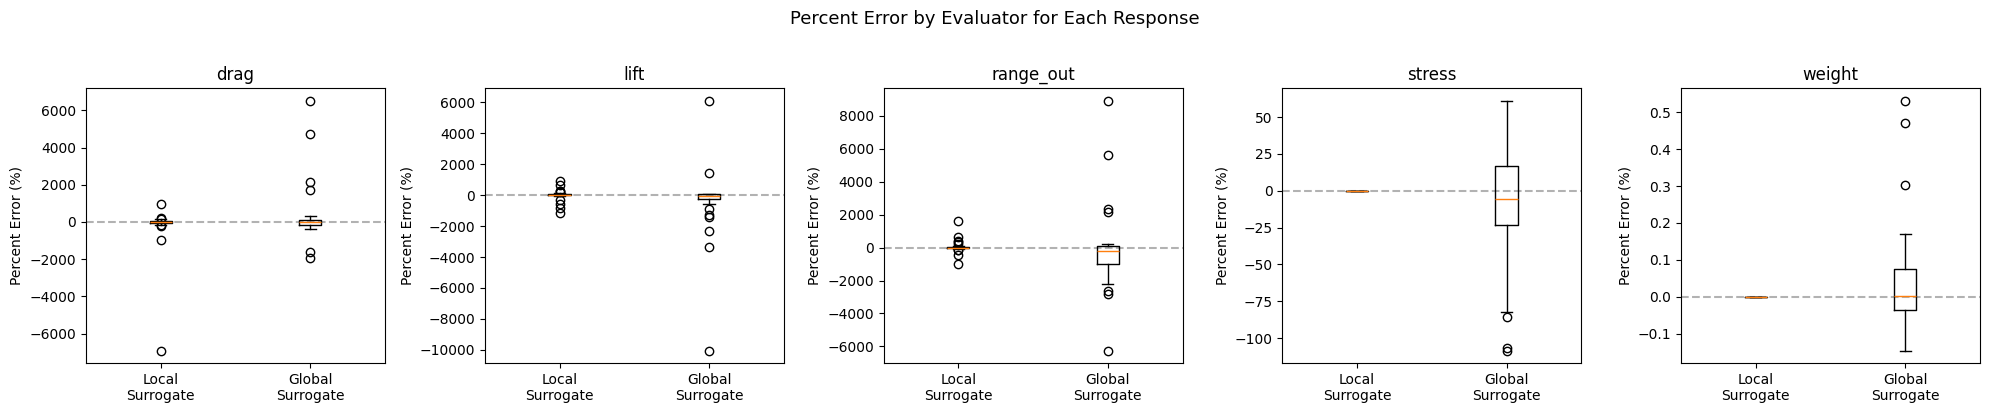

In [17]:
# --- Percent error box plots grouped by evaluator ---
fig, axes = plt.subplots(1, n_responses, figsize=(4 * n_responses, 4))

if n_responses == 1:
    axes = [axes]

for idx, response in enumerate(original_evaluator.outputs):
    ax = axes[idx]
    actual = test_sites_original[response].values

    # Compute percent errors (avoid division by zero)
    pct_errors = {}
    mask = np.abs(actual) > 1e-10  # Only compute where actual is non-zero

    if response in test_sites_modified.columns:
        pred_local = test_sites_modified[response].values
        pct_err_local = np.where(mask, (pred_local - actual) / actual * 100, 0.0)
        pct_errors['Local\nSurrogate'] = pct_err_local

    if response in test_sites_global.columns:
        pred_global = test_sites_global[response].values
        pct_err_global = np.where(mask, (pred_global - actual) / actual * 100, 0.0)
        pct_errors['Global\nSurrogate'] = pct_err_global

    if pct_errors:
        ax.boxplot(pct_errors.values(), tick_labels=pct_errors.keys())

    ax.axhline(y=0, color='k', linestyle='--', alpha=0.3)
    ax.set_ylabel('Percent Error (%)')
    ax.set_title(response)

plt.suptitle('Percent Error by Evaluator for Each Response', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()